In [226]:
# importing libraries

# standard libraries
from pathlib import Path

# data handling
import pandas as pd
import numpy as np

# chemistry
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors

# plots
import matplotlib.pyplot as plt

# ML - preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

# ML - model selection
from sklearn.model_selection import train_test_split

In [227]:
# function to save plots in directory

def save_plot(name, path="results/plots"):
    path = Path(path) # converting path from string to Path object (pathlib library)
    path.mkdir(parents=True, exist_ok=True)
    plt.savefig(path / f"{name}.png")

In [228]:
# colormap for matplotlib

cmap = "viridis"

In [229]:
# reading dataset

#!wget -P data/raw https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz

tox21_df = pd.read_csv("data/raw/tox21.csv.gz")

# Exploratory Data Analysis

In [230]:
tox21_df.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [231]:
print(f"Dimensioni del dataframe prima della pulizia: {tox21_df.shape}")

Dimensioni del dataframe prima della pulizia: (7831, 14)


In [232]:
# filtering molecules not processed by MolFromSmiles function

df = tox21_df[tox21_df["smiles"].apply(lambda x: Chem.MolFromSmiles(x) is not None)].reset_index(drop=True)

[20:48:36] WARNING: not removing hydrogen atom without neighbors
[20:48:36] Explicit valence for atom # 8 Al, 6, is greater than permitted
[20:48:36] Explicit valence for atom # 3 Al, 6, is greater than permitted
[20:48:36] Explicit valence for atom # 4 Al, 6, is greater than permitted
[20:48:36] Explicit valence for atom # 4 Al, 6, is greater than permitted
[20:48:36] Explicit valence for atom # 9 Al, 6, is greater than permitted
[20:48:36] Explicit valence for atom # 5 Al, 6, is greater than permitted
[20:48:36] Explicit valence for atom # 16 Al, 6, is greater than permitted
[20:48:37] Explicit valence for atom # 20 Al, 6, is greater than permitted


In [233]:
print(f"Dimensioni del dataframe dopo la pulizia: {df.shape}")

Dimensioni del dataframe dopo la pulizia: (7823, 14)


In [234]:
df["mol_id"].nunique()

7823

Example of 3 random molecules from the dataset:


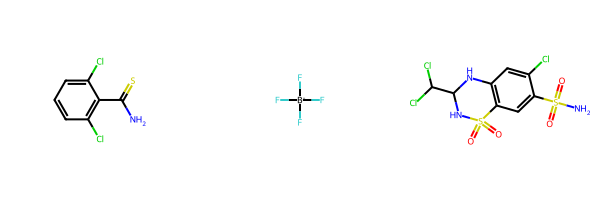

In [235]:
print("Example of 3 random molecules from the dataset:")

mols = [Chem.MolFromSmiles(s) for s in df["smiles"].sample(n=3)]
Draw.MolsToGridImage(mols)

In [236]:
df.columns

Index(['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
       'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53',
       'mol_id', 'smiles'],
      dtype='str')

In [237]:
targets = df.columns[:-2]

print("The bioassays are: ")
for i in range(len(targets)):
  print(f"{i+1}. {targets[i]}")

The bioassays are: 
1. NR-AR
2. NR-AR-LBD
3. NR-AhR
4. NR-Aromatase
5. NR-ER
6. NR-ER-LBD
7. NR-PPAR-gamma
8. SR-ARE
9. SR-ATAD5
10. SR-HSE
11. SR-MMP
12. SR-p53


In [238]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7823 entries, 0 to 7822
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NR-AR          7258 non-null   float64
 1   NR-AR-LBD      6751 non-null   float64
 2   NR-AhR         6542 non-null   float64
 3   NR-Aromatase   5815 non-null   float64
 4   NR-ER          6186 non-null   float64
 5   NR-ER-LBD      6948 non-null   float64
 6   NR-PPAR-gamma  6443 non-null   float64
 7   SR-ARE         5825 non-null   float64
 8   SR-ATAD5       7065 non-null   float64
 9   SR-HSE         6460 non-null   float64
 10  SR-MMP         5804 non-null   float64
 11  SR-p53         6767 non-null   float64
 12  mol_id         7823 non-null   str    
 13  smiles         7823 non-null   str    
dtypes: float64(12), str(2)
memory usage: 855.8 KB


In [239]:
df.isnull().sum()

NR-AR             565
NR-AR-LBD        1072
NR-AhR           1281
NR-Aromatase     2008
NR-ER            1637
NR-ER-LBD         875
NR-PPAR-gamma    1380
SR-ARE           1998
SR-ATAD5          758
SR-HSE           1363
SR-MMP           2019
SR-p53           1056
mol_id              0
smiles              0
dtype: int64

In [240]:
for target in targets:
    data_counts = df.groupby(target).size()
    print(data_counts)

NR-AR
0.0    6950
1.0     308
dtype: int64
NR-AR-LBD
0.0    6514
1.0     237
dtype: int64
NR-AhR
0.0    5774
1.0     768
dtype: int64
NR-Aromatase
0.0    5515
1.0     300
dtype: int64
NR-ER
0.0    5395
1.0     791
dtype: int64
NR-ER-LBD
0.0    6599
1.0     349
dtype: int64
NR-PPAR-gamma
0.0    6257
1.0     186
dtype: int64
SR-ARE
0.0    4883
1.0     942
dtype: int64
SR-ATAD5
0.0    6801
1.0     264
dtype: int64
SR-HSE
0.0    6088
1.0     372
dtype: int64
SR-MMP
0.0    4886
1.0     918
dtype: int64
SR-p53
0.0    6344
1.0     423
dtype: int64


In [241]:
# summary of dataset

summary = []

for target in targets:
    not_toxic = (df[target] == 0).sum()
    toxic = (df[target] == 1).sum()
    nan = (df[target]).isnull().sum()

    total = not_toxic + toxic + nan
    valid_total = not_toxic + toxic

    summary.append({
        "Target": col, 
        "Not Toxic": not_toxic,
        "Toxic": toxic,
        "Missing": nan,
        "Toxic % (on valid)": (toxic / valid_total) * 100,
        "Not Toxic % (on valid)": (not_toxic / valid_total) * 100,
        "Missing % (on total)": (nan / total * 100)
        })

summary_df = pd.DataFrame(summary)

In [242]:
counts_df = summary_df[["Target", "Not Toxic", "Toxic", "Missing"]]
print(counts_df)

    Target  Not Toxic  Toxic  Missing
0   SR-p53       6950    308      565
1   SR-p53       6514    237     1072
2   SR-p53       5774    768     1281
3   SR-p53       5515    300     2008
4   SR-p53       5395    791     1637
5   SR-p53       6599    349      875
6   SR-p53       6257    186     1380
7   SR-p53       4883    942     1998
8   SR-p53       6801    264      758
9   SR-p53       6088    372     1363
10  SR-p53       4886    918     2019
11  SR-p53       6344    423     1056


In [243]:
# printing missing values

missing_df = summary_df[["Target", "Missing % (on total)"]]

print(
    missing_df
    .sort_values(by="Missing % (on total)", ascending=False)
    .to_string(formatters={
        "Missing % (on total)": lambda x: f"{x:.2f}"
    })
)

    Target Missing % (on total)
10  SR-p53                25.81
3   SR-p53                25.67
7   SR-p53                25.54
4   SR-p53                20.93
6   SR-p53                17.64
9   SR-p53                17.42
2   SR-p53                16.37
1   SR-p53                13.70
11  SR-p53                13.50
5   SR-p53                11.18
8   SR-p53                 9.69
0   SR-p53                 7.22


In [244]:
# printing class distribution between toxic and not toxic

balance_df = summary_df[["Target", "Toxic % (on valid)", "Not Toxic % (on valid)"]]

print(
    balance_df
    .sort_values(by="Toxic % (on valid)", ascending=False)
    .to_string(formatters={
        "Toxic % (on valid)": lambda x: f"{x:.2f}%",
        "Not Toxic % (on valid)": lambda x: f"{x:.2f}%",
    })
)

    Target Toxic % (on valid) Not Toxic % (on valid)
7   SR-p53             16.17%                 83.83%
10  SR-p53             15.82%                 84.18%
4   SR-p53             12.79%                 87.21%
2   SR-p53             11.74%                 88.26%
11  SR-p53              6.25%                 93.75%
9   SR-p53              5.76%                 94.24%
3   SR-p53              5.16%                 94.84%
5   SR-p53              5.02%                 94.98%
0   SR-p53              4.24%                 95.76%
8   SR-p53              3.74%                 96.26%
1   SR-p53              3.51%                 96.49%
6   SR-p53              2.89%                 97.11%


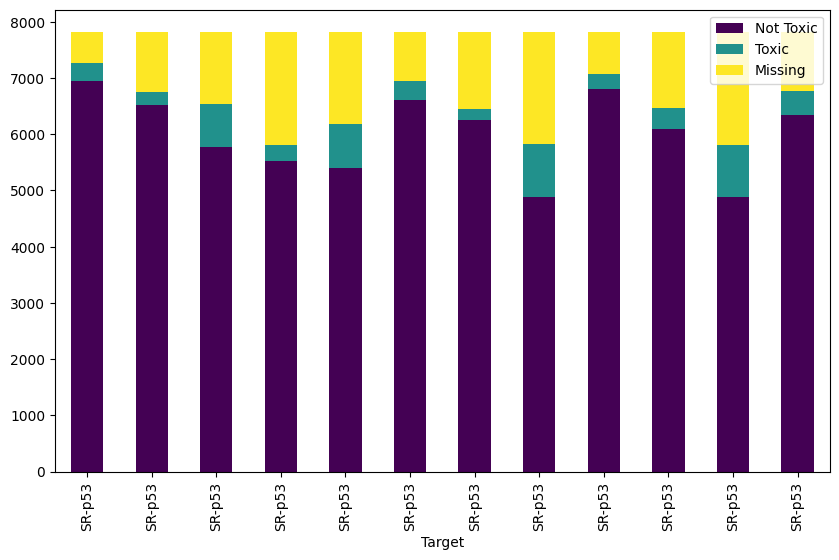

In [245]:
# visualizing classes distributions

ax = counts_df.set_index("Target").plot.bar(stacked=True, figsize=(10, 6), cmap=cmap)
fig = ax.get_figure()
save_plot("class-distribution")
plt.show()

In [246]:
NR_AhR_df = df[["NR-AhR", "smiles"]].dropna().reset_index(drop=True)
print(NR_AhR_df)

      NR-AhR                                             smiles
0        1.0                       CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1        0.0                          CCN1C(=O)NC(c2ccccc2)C1=O
2        0.0                    CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
3        0.0                          CC(O)(P(=O)(O)O)P(=O)(O)O
4        0.0               CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C
...      ...                                                ...
6537     0.0                     CCCn1c(=O)[nH]c(=O)c2[nH]cnc21
6538     0.0                 CCCNCC(O)COc1ccccc1C(=O)CCc1ccccc1
6539     0.0  CC(=O)[C@H]1CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(...
6540     0.0  C[C@]12CC[C@H]3[C@@H](CCC4=CC(=O)CC[C@@]43C)[C...
6541     0.0  C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C...

[6542 rows x 2 columns]


In [247]:
y = NR_AhR_df["NR-AhR"]
print(y)

0       1.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
6537    0.0
6538    0.0
6539    0.0
6540    0.0
6541    0.0
Name: NR-AhR, Length: 6542, dtype: float64


# Feature extraction of molecular descriptors

In [248]:
# extracting molecular descriptors

desc_names = [x[0] for x in Descriptors.descList]
desc_funcs = [x[1] for x in Descriptors.descList]

all_desc_values = []

for smiles in NR_AhR_df["smiles"]:
    mol = Chem.MolFromSmiles(smiles)
    desc_values = [f(mol) for f in desc_funcs]
    all_desc_values.append(desc_values)

desc_df = pd.DataFrame(all_desc_values, columns=desc_names)
desc_df.head()

[20:48:38] WARNING: not removing hydrogen atom without neighbors
[20:48:38] WARNING: not removing hydrogen atom without neighbors


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.107593,11.107593,0.073011,-3.723219,0.900283,11.875000,258.324,248.244,258.013284,86,...,0,1,0,0,0,1,0,0,0,0
1,11.790004,11.790004,0.172500,-0.515139,0.738013,20.600000,204.229,192.133,204.089878,78,...,0,0,0,0,0,0,0,0,0,1
2,12.570517,12.570517,0.042633,-0.042633,0.822261,12.500000,276.424,248.200,276.220164,112,...,0,0,0,0,0,0,0,0,0,0
3,10.251875,10.251875,0.383488,-5.197724,0.365583,15.090909,206.027,197.963,205.974526,68,...,0,0,0,0,0,0,0,0,0,0
4,5.538351,5.538351,0.306911,-0.365434,0.497486,14.700000,290.444,256.172,290.245710,122,...,0,0,0,0,0,0,0,0,0,0


In [249]:
desc_df.shape

(6542, 217)

In [250]:
desc_df.columns

Index(['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex',
       'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt',
       'NumValenceElectrons',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='str', length=217)

In [251]:
constant_cols = [col for col in desc_df.columns if desc_df[col].nunique() == 1]
print(constant_cols)

['SMR_VSA8', 'SlogP_VSA9', 'fr_diazo']


In [252]:
desc_df[["SMR_VSA8", "SlogP_VSA9", "fr_diazo"]]

,SMR_VSA8,SlogP_VSA9,fr_diazo
0,0.0,0.0,0
1,0.0,0.0,0
2,0.0,0.0,0
3,0.0,0.0,0
4,0.0,0.0,0
...,...,...,...
6537,0.0,0.0,0
6538,0.0,0.0,0
6539,0.0,0.0,0
6540,0.0,0.0,0


In [253]:
threshold = 0.95

corr = desc_df.corr()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

corr_pairs = (
    upper.stack()
    .reset_index()
)

corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

high_corr_pairs = corr_pairs[
    corr_pairs["Correlation"].abs() > threshold
]

high_corr_pairs = high_corr_pairs.sort_values(
    by="Correlation",
    ascending=False
)

print(f"Highly correlated feature pairs (Pearson Coefficient > {threshold}):")
print("="*30)
for a, b, val in high_corr_pairs.values:
    print(f"{a} - {b}: {val:.3f}")

Highly correlated feature pairs (Pearson Coefficient > 0.95):
MaxAbsEStateIndex - MaxEStateIndex: 1.000
NumAmideBonds - fr_amide: 1.000
fr_Ar_NH - fr_Nhpyrrole: 1.000
MolWt - ExactMolWt: 1.000
Kappa2 - Phi: 1.000
Chi1 - HeavyAtomCount: 0.999
MolWt - HeavyAtomMolWt: 0.998
HeavyAtomMolWt - ExactMolWt: 0.998
NumAromaticCarbocycles - fr_benzene: 0.998
Chi0 - HeavyAtomCount: 0.997
NumValenceElectrons - Chi0: 0.997
fr_COO - fr_COO2: 0.996
NumValenceElectrons - HeavyAtomCount: 0.995
Chi0 - Chi1: 0.994
LabuteASA - HeavyAtomCount: 0.994
Chi0n - Chi1n: 0.993
Chi1 - LabuteASA: 0.993
NumValenceElectrons - Chi1: 0.993
Chi0v - LabuteASA: 0.992
Chi0 - LabuteASA: 0.992
NumValenceElectrons - LabuteASA: 0.991
fr_phenol - fr_phenol_noOrthoHbond: 0.990
LabuteASA - MolMR: 0.989
Chi3n - Chi4n: 0.989
Chi0v - MolMR: 0.989
NumValenceElectrons - Chi0n: 0.988
fr_Ar_OH - fr_phenol: 0.988
Chi0n - Chi1: 0.984
Chi0n - HeavyAtomCount: 0.984
Chi0n - MolMR: 0.984
Chi0n - Chi0v: 0.984
Chi1 - MolMR: 0.983
NumValenceElect

# Feature selection of molecular descriptors

In [254]:
train_idx, test_idx = train_test_split(
    NR_AhR_df.index,
    test_size=0.2,
    random_state=42,
    stratify = y
)

In [255]:
control = pd.DataFrame({
    "Original": y.value_counts(normalize=True),
    "Train": y.loc[train_idx].value_counts(normalize=True),
    "Test": y.loc[test_idx].value_counts(normalize=True),
})

print(control)

        Original     Train      Test
NR-AhR                              
0.0     0.882605  0.882668  0.882353
1.0     0.117395  0.117332  0.117647


In [256]:
desc_X_train = desc_df.loc[train_idx]
desc_X_test = desc_df.loc[test_idx]

# fp_X_train = fp_df.loc[train_idx]
# fp_X_test = fp_df.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

In [257]:
# delete infinite features

mask = np.isfinite(desc_X_train).all()

desc_X_train_fin = desc_X_train.loc[:, mask]
desc_X_test_fin = desc_X_test.loc[:, mask]

In [258]:
desc_X_train.shape

(5233, 217)

In [259]:
desc_X_train_fin.shape

(5233, 205)

In [260]:
# delete constant features

selector = VarianceThreshold(0.0)

desc_X_train_clean = selector.fit_transform(desc_X_train_fin)
desc_X_test_clean = selector.transform(desc_X_test_fin)

In [261]:
desc_X_train_fin.shape

(5233, 205)

In [262]:
desc_X_train_clean.shape

(5233, 202)

In [263]:
# scaling features

scaler = StandardScaler()
desc_X_train_scaled = scaler.fit_transform(desc_X_train_clean)
desc_X_test_scaled = scaler.transform(desc_X_test_clean)

In [264]:
# Check the Standardization
print('\nCheck Standardization:')
print(f'Mean train original: {desc_X_train_clean.mean():.2f}')
print(f'Mean train scaled: {desc_X_train_scaled.mean():.2f} (should be near 0)')
print(f'Std train original: {desc_X_train_clean.std():.2f}')
print(f'Std train scaled: {desc_X_train_scaled.std():.2f} (should be near 1)')


Check Standardization:
Mean train original: 108062582891604276232558786650308608.00
Mean train scaled: 0.00 (should be near 0)
Std train original: 111101542046232239637580062875017281536.00
Std train scaled: 1.00 (should be near 1)


In [266]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

# evaluate optimal k value of features based on PR-AUC

n_features = desc_X_train_scaled.shape[1]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for k in range(1, n_features + 1):
    selector = SelectKBest(score_func=mutual_info_classif, k=k)
    X_train_k = selector.fit_transform(desc_X_train_scaled, y_train)

    model = LogisticRegression(solver='lbfgs', max_iter=5000, class_weight="balanced")
    cv_score = cross_val_score(model, X_train_k, y_train, cv=skf, scoring='average_precision')

    mean_pr_auc = np.mean(cv_score)
    results.append((k, mean_pr_auc))
    print(f"K={k:>3d} --> PR-AUC = {mean_pr_auc:.4f}")

best_k, best_pr_auc = max(results, key=lambda x: x[1])
print(f"\nBest PR-AUC [{best_pr_auc:.4f}] obtained with k = {best_k}")


K=  1 --> PR-AUC = 0.1833
K=  2 --> PR-AUC = 0.2166
K=  3 --> PR-AUC = 0.2809
K=  4 --> PR-AUC = 0.3652
K=  5 --> PR-AUC = 0.2851
K=  6 --> PR-AUC = 0.3723
K=  7 --> PR-AUC = 0.3768
K=  8 --> PR-AUC = 0.3786
K=  9 --> PR-AUC = 0.3957
K= 10 --> PR-AUC = 0.4042
K= 11 --> PR-AUC = 0.3968
K= 12 --> PR-AUC = 0.3971
K= 13 --> PR-AUC = 0.4013
K= 14 --> PR-AUC = 0.3903
K= 15 --> PR-AUC = 0.4004
K= 16 --> PR-AUC = 0.4043
K= 17 --> PR-AUC = 0.4082
K= 18 --> PR-AUC = 0.4055
K= 19 --> PR-AUC = 0.4155
K= 20 --> PR-AUC = 0.4033
K= 21 --> PR-AUC = 0.4151
K= 22 --> PR-AUC = 0.4104
K= 23 --> PR-AUC = 0.4202
K= 24 --> PR-AUC = 0.4168
K= 25 --> PR-AUC = 0.4259
K= 26 --> PR-AUC = 0.4313
K= 27 --> PR-AUC = 0.4215
K= 28 --> PR-AUC = 0.4233
K= 29 --> PR-AUC = 0.4507
K= 30 --> PR-AUC = 0.4469
K= 31 --> PR-AUC = 0.4580
K= 32 --> PR-AUC = 0.4486
K= 33 --> PR-AUC = 0.4470
K= 34 --> PR-AUC = 0.4600
K= 35 --> PR-AUC = 0.4560
K= 36 --> PR-AUC = 0.4502
K= 37 --> PR-AUC = 0.4575
K= 38 --> PR-AUC = 0.4570
K= 39 --> PR

In [273]:
# rifitta il selector sul training set intero con best_k
selector = SelectKBest(score_func=mutual_info_classif, k=best_k)
selector.fit(desc_X_train_scaled, y_train)

import pandas as pd

feature_scores = pd.DataFrame({
    "feature": desc_X_train.columns,
    "MI_score": selector.scores_
})

feature_scores = feature_scores.sort_values("MI_score", ascending=False)

print(feature_scores.head(20))

ValueError: All arrays must be of the same length